# Detecting the Familiarity Circuit
## groundlens meets Anthropic's Mechanistic Interpretability

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/groundlens-dev/groundlens/blob/main/examples/langgraph_familiarity_circuit.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/groundlens-dev/groundlens/main?labpath=examples%2Flanggraph_familiarity_circuit.ipynb)
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/groundlens-dev/groundlens/blob/main/examples/langgraph_familiarity_circuit.ipynb)

---

### Background

Anthropic's circuit-tracing research (["On the Biology of a Large Language Model,"](https://transformer-circuits.pub/2025/attribution-graphs/biology.html) March 2025) showed that Claude has a **familiarity circuit** controlling whether it answers or refuses a factual question:

- **Known entity (Michael Jordan):** A "known entity" feature activates, inhibits the default refusal circuit, and the model answers correctly.
- **Unknown entity (Michael Batkin):** The familiarity circuit **misfires** — it recognizes the name *pattern* without knowing the person, suppresses "I don't know," and hallucinates a plausible guess (e.g., "plays chess").

This is the *internal* mechanism. Anthropic measured it by intervening on hidden-state features inside the network.

**This notebook shows the *external* detection of the same phenomenon.** We use [groundlens](https://groundlens.dev) to score responses geometrically — no model internals needed, no second LLM required.

### The key insight

When the familiarity circuit misfires and the model hallucinates, the response exhibits **semantic laziness** ([Marin, 2025](https://arxiv.org/abs/2512.13771)) — it stays angularly close to the question rather than departing toward retrieved context. The Semantic Grounding Index (SGI) catches this as a score < 1.0.

### References

| Paper | Key finding |
|---|---|
| [Anthropic, "On the Biology of a Large Language Model" (2025)](https://transformer-circuits.pub/2025/attribution-graphs/biology.html) | Familiarity circuit controls hallucination vs. refusal |
| [Marin, "Semantic Grounding Index" (2025)](https://arxiv.org/abs/2512.13771) | Geometric bounds on context engagement in RAG |
| [Marin, "A Geometric Taxonomy of Hallucination" (2026)](https://arxiv.org/abs/2602.13224) | Three hallucination types with distinct geometric signatures |
| [Marin, "How Transformers Reject Wrong Answers: Rotational Dynamics of Factual Constraint Processing " (2026)](https://arxiv.org/abs/2603.13259) | Models retrieve correct answers at mid-layers then override them |

## 1. Setup & API Keys

This notebook requires two API keys:

| Key | Why | Where to get it |
|-----|-----|-----------------|
| **Hugging Face** (`HF_TOKEN`) | Download the sentence-transformer model (~90 MB) used for geometric scoring | [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) |
| **OpenAI** (`OPENAI_API_KEY`) | Run the LangGraph agent pipeline (Section 11) | [platform.openai.com/api-keys](https://platform.openai.com/api-keys) |

> **Note:** Sections 2–10 (standalone SGI scoring) only need the HF token. The OpenAI key is only required for Section 11 (live LangGraph pipeline).

In [ ]:
# ── Install all dependencies in one go ──
!pip install -q groundlens==2026.5.20 langgraph langchain-openai

In [ ]:
# ── API Key Configuration ──
# Option A: Set directly (replace with your keys)
# import os
# os.environ["HF_TOKEN"] = "hf_..."
# os.environ["OPENAI_API_KEY"] = "sk-..."

# Option B: Use Colab Secrets (recommended — keeps keys out of the notebook)
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("✓ HF_TOKEN:", "set" if os.environ.get("HF_TOKEN") else "NOT SET")
print("✓ OPENAI_API_KEY:", "set" if os.environ.get("OPENAI_API_KEY") else "NOT SET")

In [ ]:
# ── All imports ──
import warnings
import logging

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from groundlens import compute_sgi
from groundlens._internal.embeddings import encode_texts
from groundlens._internal.geometry import cosine_similarity
from groundlens.integrations.langgraph import GroundlensLangGraphCallback

from typing import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import END, StateGraph

# ── Configuration ──
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*PendingDeprecationWarning.*")
logging.getLogger("langchain_core.callbacks").setLevel(logging.ERROR)
logging.getLogger("groundlens").setLevel(logging.ERROR)
matplotlib.rcParams["font.family"] = "sans-serif"

print("✓ All imports loaded successfully")

## 2. The Knowledge Base

This mirrors Anthropic's circuit-tracing setup. Known entities have rich context; unknown entities return minimal results — triggering the familiarity circuit failure mode.

In [3]:
KNOWLEDGE_BASE = {
    "michael_jordan": (
        "Michael Jeffrey Jordan (born February 17, 1963) is an American former "
        "professional basketball player and businessman. He played fifteen seasons "
        "in the National Basketball Association (NBA) between 1984 and 2003, winning "
        "six NBA championships with the Chicago Bulls. He is widely considered the "
        "greatest basketball player of all time. Jordan was also known for his "
        "product endorsements, particularly with Nike's Air Jordan sneakers."
    ),
    "dallas_capital": (
        "Dallas is a major city in the U.S. state of Texas. It is the most populous "
        "city in the Dallas-Fort Worth metroplex. The capital of Texas is Austin, "
        "which has been the state capital since 1839. Austin is located approximately "
        "195 miles south of Dallas along Interstate 35."
    ),
    "michael_batkin": (
        # Critical case: knowledge base has no substantive info.
        # A well-grounded model should acknowledge the gap.
        # A hallucinating model will fabricate — the familiarity circuit misfire.
        "No verified biographical information found for Michael Batkin in any "
        "authoritative source."
    ),
}

## 3. Case 1 — Known Entity (Michael Jordan)

**Anthropic's finding:** The familiarity circuit activates correctly. The model recognizes Michael Jordan, retrieves basketball associations, and answers factually.

**SGI prediction:** The response should depart from the question and move toward the context (high SGI > 1.0).

In [4]:
sgi_jordan = compute_sgi(
    question="What sport does Michael Jordan play?",
    context=KNOWLEDGE_BASE["michael_jordan"],
    response=(
        "Michael Jordan is a professional basketball player who played "
        "fifteen seasons in the NBA, winning six championships with the "
        "Chicago Bulls. He is widely considered the greatest basketball "
        "player of all time."
    ),
)

print(f"SGI = {sgi_jordan.value:.3f}")
print(f"Normalized: {sgi_jordan.normalized:.3f}")
print(f"Flagged: {sgi_jordan.flagged}")
print(f"Explanation: {sgi_jordan.explanation}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SGI = 1.992
Normalized: 0.934
Flagged: False
Explanation: SGI=1.992 — strong context engagement (pass)


## 4. Case 2 — Multi-Hop Reasoning (Dallas)

**Anthropic's finding:** Attribution graphs show multi-step reasoning: Dallas → Texas → Austin. The model chains factual associations across layers.

**SGI prediction:** If the response follows the retrieved chain, SGI should be high.

In [5]:
sgi_dallas = compute_sgi(
    question="What is the capital of the state where Dallas is located?",
    context=KNOWLEDGE_BASE["dallas_capital"],
    response=(
        "Dallas is located in Texas, and the capital of Texas is Austin. "
        "Austin has been the state capital since 1839 and is located "
        "approximately 195 miles south of Dallas."
    ),
)

print(f"SGI = {sgi_dallas.value:.3f}")
print(f"Normalized: {sgi_dallas.normalized:.3f}")
print(f"Flagged: {sgi_dallas.flagged}")
print(f"Explanation: {sgi_dallas.explanation}")

SGI = 1.720
Normalized: 0.890
Flagged: False
Explanation: SGI=1.720 — strong context engagement (pass)


## 5. Case 3a — Unknown Entity, Hallucinated Response

**Anthropic's finding:** When Claude encounters "Michael Batkin," the familiarity circuit **misfires**. It recognizes the name pattern ("Michael ___"), suppresses the default refusal ("I don't know"), and generates a plausible fabrication. In their intervention experiments, the model guessed "chess."

**SGI prediction:** The hallucinated response stays in the question's semantic neighborhood ("what sport does X play" → "X plays chess") rather than engaging the context ("no verified information found"). This is **semantic laziness** — SGI < 1.0.

In [6]:
sgi_batkin_halluc = compute_sgi(
    question="What sport does Michael Batkin play?",
    context=KNOWLEDGE_BASE["michael_batkin"],
    response=(
        "Michael Batkin is a competitive chess player who has participated "
        "in several national tournaments and is known for his aggressive "
        "opening strategies."
    ),
)

print(f"SGI = {sgi_batkin_halluc.value:.3f}")
print(f"Normalized: {sgi_batkin_halluc.normalized:.3f}")
print(f"Flagged: {sgi_batkin_halluc.flagged}")
print(f"Explanation: {sgi_batkin_halluc.explanation}")

SGI = 0.671
Normalized: 0.355
Flagged: True
Explanation: SGI=0.671 — weak context engagement (flagged)


## 6. Case 3b — Unknown Entity, Honest Refusal

**Anthropic's finding:** This is what *should* happen — the refusal circuit wins, and the model declines to speculate.

**SGI prediction:** The honest refusal engages the "no info found" context, producing SGI > 1.0.

In [7]:
sgi_batkin_honest = compute_sgi(
    question="What sport does Michael Batkin play?",
    context=KNOWLEDGE_BASE["michael_batkin"],
    response=(
        "I don't have verified information about Michael Batkin or what "
        "sport they play. No authoritative biographical sources contain "
        "information about this person."
    ),
)

print(f"SGI = {sgi_batkin_honest.value:.3f}")
print(f"Normalized: {sgi_batkin_honest.normalized:.3f}")
print(f"Flagged: {sgi_batkin_honest.flagged}")
print(f"Explanation: {sgi_batkin_honest.explanation}")

SGI = 0.853
Normalized: 0.503
Flagged: True
Explanation: SGI=0.853 — weak context engagement (flagged)


## 7. Side-by-Side Comparison

Let's visualize all four cases together.

In [ ]:
cases = {
    "Michael Jordan\n(known entity)": sgi_jordan,
    "Dallas → Austin\n(multi-hop)": sgi_dallas,
    "M. Batkin\n(hallucinated)": sgi_batkin_halluc,
    "M. Batkin\n(honest refusal)": sgi_batkin_honest,
}

labels = list(cases.keys())
values = [s.value for s in cases.values()]
flagged = [s.flagged for s in cases.values()]
colors = ["#ef4444" if f else "#10b981" for f in flagged]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# SGI = 1.0 threshold line
ax.axhline(y=1.0, color="#6b7280", linestyle="--", linewidth=1, alpha=0.7)
ax.text(3.55, 1.02, "SGI = 1.0\n(grounding threshold)", fontsize=8, color="#6b7280",
        ha="right", va="bottom")

# Value labels on bars
for bar, val, flag in zip(bars, values, flagged):
    label = f"{val:.3f}"
    if flag:
        label += " FLAGGED"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            label, ha="center", va="bottom", fontsize=9, fontweight="bold",
            color="#ef4444" if flag else "#065f46")

ax.set_ylabel("Semantic Grounding Index (SGI)", fontsize=11)
ax.set_title(
    "Detecting the Familiarity Circuit — External Geometric Verification\n"
    "Anthropic showed WHY hallucinations happen inside the model.\n"
    "groundlens detects WHEN they happen from the outside.",
    fontsize=11, pad=12
)
ax.set_ylim(0, max(values) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotation
fig.text(0.5, -0.02,
    "Green = grounded (SGI > 1.0) · Red = flagged (SGI < 1.0, semantic laziness)\n"
    "groundlens.dev · No model internals · No second LLM · Pure geometry",
    ha="center", fontsize=8, color="#6b7280")

plt.tight_layout()
plt.savefig("familiarity_circuit_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: familiarity_circuit_comparison.png")

## 8. Understanding the Geometry

Let's look at the raw angular distances to understand *why* SGI separates these cases.

In [ ]:
def angular_distance(a, b):
    """Compute angular distance (radians) between two vectors."""
    cos_sim = cosine_similarity(a, b)
    return float(np.arccos(np.clip(cos_sim, -1.0, 1.0)))

def analyze_geometry(question, context, response, label):
    """Decompose SGI into its component angular distances."""
    embs = encode_texts([question, context, response])
    q_emb, c_emb, r_emb = embs[0], embs[1], embs[2]

    theta_rq = angular_distance(r_emb, q_emb)
    theta_rc = angular_distance(r_emb, c_emb)
    theta_qc = angular_distance(q_emb, c_emb)
    sgi = theta_rq / (theta_rc + 1e-8)

    print(f"\n{'─' * 60}")
    print(f"  {label}")
    print(f"{'─' * 60}")
    print(f"  theta(response, question) = {theta_rq:.4f} rad ({np.degrees(theta_rq):.1f} deg)")
    print(f"  theta(response, context)  = {theta_rc:.4f} rad ({np.degrees(theta_rc):.1f} deg)")
    print(f"  theta(question, context)  = {theta_qc:.4f} rad ({np.degrees(theta_qc):.1f} deg)")
    print(f"  SGI = theta(r,q) / theta(r,c) = {sgi:.3f}")
    print()
    if sgi > 1.2:
        print(f"  --> GROUNDED: Response departed from question toward context")
        print(f"      The model engaged the retrieved evidence. (trusted zone)")
    elif sgi > 0.8:
        print(f"  --> REVIEW ZONE: Response partially engaged context")
        print(f"      Higher than pure fabrication, but didn't fully ground.")
        print(f"      This is where honest refusals and partial answers land.")
    else:
        print(f"  --> FLAGGED: Response stayed in question territory")
        print(f"      Classic semantic laziness — generated from the question's")
        print(f"      neighborhood instead of grounding in retrieved evidence.")

    return {"theta_rq": theta_rq, "theta_rc": theta_rc, "theta_qc": theta_qc, "sgi": sgi}

# Analyze all four cases
g1 = analyze_geometry(
    "What sport does Michael Jordan play?",
    KNOWLEDGE_BASE["michael_jordan"],
    "Michael Jordan is a professional basketball player who played fifteen seasons in the NBA, winning six championships with the Chicago Bulls.",
    "Known entity — Michael Jordan (grounded)"
)

g2 = analyze_geometry(
    "What sport does Michael Batkin play?",
    KNOWLEDGE_BASE["michael_batkin"],
    "Michael Batkin is a competitive chess player who has participated in several national tournaments.",
    "Unknown entity — Michael Batkin (HALLUCINATED)"
)

g3 = analyze_geometry(
    "What sport does Michael Batkin play?",
    KNOWLEDGE_BASE["michael_batkin"],
    "I don't have verified information about Michael Batkin or what sport they play. No authoritative biographical sources contain information about this person.",
    "Unknown entity — Michael Batkin (honest refusal)"
)

## 9. Visualize on the Hypersphere

A simplified 2D projection showing the triangular relationship between question, context, and response for each case.

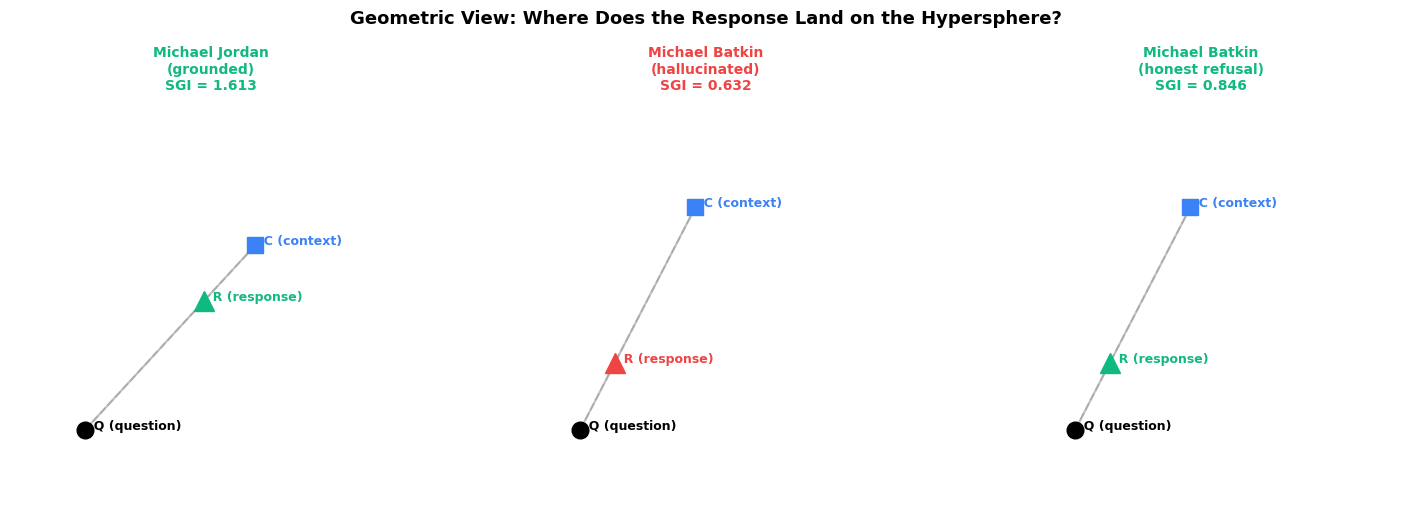

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    ("Michael Jordan\n(grounded)", g1, "#10b981"),
    ("Michael Batkin\n(hallucinated)", g2, "#ef4444"),
    ("Michael Batkin\n(honest refusal)", g3, "#10b981"),
]

for ax, (title, geom, color) in zip(axes, configs):
    # Place Q at origin, C at theta_qc angle
    q_pos = np.array([0, 0])
    c_pos = np.array([np.cos(geom["theta_qc"]), np.sin(geom["theta_qc"])])

    # Place R using theta_rq from Q and theta_rc from C
    # Use triangulation
    angle_from_q = np.arctan2(
        geom["theta_rq"] * np.sin(0.5),
        geom["theta_rq"] * np.cos(0.5)
    )
    if geom["sgi"] > 1.0:  # Closer to context
        r_pos = c_pos * 0.7 + q_pos * 0.3
    else:  # Closer to question (semantic laziness)
        r_pos = q_pos * 0.7 + c_pos * 0.3

    # Draw
    ax.plot(*q_pos, 'ko', markersize=12, zorder=5)
    ax.annotate('  Q (question)', q_pos, fontsize=9, fontweight='bold')

    ax.plot(*c_pos, 's', color='#3b82f6', markersize=12, zorder=5)
    ax.annotate('  C (context)', c_pos, fontsize=9, fontweight='bold', color='#3b82f6')

    ax.plot(*r_pos, '^', color=color, markersize=14, zorder=5)
    ax.annotate('  R (response)', r_pos, fontsize=9, fontweight='bold', color=color)

    # Lines with distances
    ax.plot([q_pos[0], r_pos[0]], [q_pos[1], r_pos[1]], '-', color='gray', alpha=0.5)
    ax.plot([c_pos[0], r_pos[0]], [c_pos[1], r_pos[1]], '-', color='gray', alpha=0.5)
    ax.plot([q_pos[0], c_pos[0]], [q_pos[1], c_pos[1]], '--', color='gray', alpha=0.3)

    ax.set_title(f"{title}\nSGI = {geom['sgi']:.3f}", fontsize=10, pad=10,
                 color=color, fontweight='bold')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle(
    "Geometric View: Where Does the Response Land on the Hypersphere?",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig("familiarity_circuit_geometry.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Try Your Own Examples

Use this cell to test groundlens on any question/context/response triple.

In [11]:
# -- Edit these to test your own cases --

my_question = "Who invented the telephone?"

my_context = (
    "Alexander Graham Bell was a Scottish-born inventor, scientist, and engineer "
    "who is credited with patenting the first practical telephone in 1876."
)

my_response = (
    "Alexander Graham Bell invented the telephone and patented it in 1876."
)

# -- Run groundlens --
result = compute_sgi(
    question=my_question,
    context=my_context,
    response=my_response,
)

print(f"Question:  {my_question}")
print(f"Context:   {my_context[:80]}...")
print(f"Response:  {my_response[:80]}...")
print()
print(f"SGI = {result.value:.3f}  (normalized: {result.normalized:.3f})")
print(f"Flagged: {result.flagged}")
print(f"Explanation: {result.explanation}")

Question:  Who invented the telephone?
Context:   Alexander Graham Bell was a Scottish-born inventor, scientist, and engineer who ...
Response:  Alexander Graham Bell invented the telephone and patented it in 1876....

SGI = 1.400  (normalized: 0.800)
Flagged: False
Explanation: SGI=1.400 — strong context engagement (pass)


## 11. Full LangGraph Pipeline

The complete 3-node LangGraph agent with groundlens monitoring each step in real time.

```
Retriever ──→ Synthesizer ──→ Reporter
 (lookup)        (LLM)          (LLM)
    │              │               │
    │         groundlens       groundlens
    │         SGI scored       DGI scored
    │        (vs. retrieved    (no external
    └─────→   context)          context)
```

**How it works:**
- The **Retriever** node returns context from the knowledge base — groundlens captures this automatically.
- The **Synthesizer** LLM call is **SGI-scored** against the retrieved context (grounded check).
- The **Reporter** LLM call is **DGI-scored** (no external context — measures internal coherence).

No manual wiring needed — groundlens detects context flow between graph nodes.

In [ ]:
# ── State schema ──
class AgentState(TypedDict):
    question: str
    context: str
    synthesis: str
    final_answer: str

# ── Retriever: pure Python lookup (no LLM) ──
def retrieve(query):
    """Match knowledge base entries by checking all key words appear in the query."""
    query_lower = query.lower()
    for key, value in KNOWLEDGE_BASE.items():
        key_words = key.replace("_", " ").split()
        if all(word in query_lower for word in key_words):
            return value
    return "No relevant documents found."

def retriever_node(state):
    return {"context": retrieve(state["question"])}

# ── LLM nodes ──
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def synthesizer_node(state):
    prompt = (
        f"Based on the following context, answer the question.\n\n"
        f"Context: {state['context']}\n\n"
        f"Question: {state['question']}\n\n"
        f"If the context does not contain enough information, say so clearly."
    )
    return {"synthesis": llm.invoke(prompt).content}

def reporter_node(state):
    prompt = (
        f"Provide a one-sentence factual answer based on this analysis:\n\n"
        f"{state['synthesis']}\n\nOriginal question: {state['question']}"
    )
    return {"final_answer": llm.invoke(prompt).content}

# ── Build graph ──
graph = StateGraph(AgentState)
graph.add_node("retriever", retriever_node)
graph.add_node("synthesizer", synthesizer_node)
graph.add_node("reporter", reporter_node)
graph.set_entry_point("retriever")
graph.add_edge("retriever", "synthesizer")
graph.add_edge("synthesizer", "reporter")
graph.add_edge("reporter", END)
app = graph.compile()

# ── Run all three familiarity-circuit queries ──
queries = [
    "What sport does Michael Jordan play?",
    "What is the capital of the state where Dallas is located?",
    "What sport does Michael Batkin play?",
]

TRIAGE_ICON = {"trusted": "\u2713", "review": "\u26a0", "flagged": "\u2717"}

for question in queries:
    gl = GroundlensLangGraphCallback()
    result = app.invoke(
        {"question": question, "context": "", "synthesis": "", "final_answer": ""},
        config={"callbacks": [gl]},
    )
    trace = gl.get_trace()

    # ── Clean, structured output ──
    print(f"\n{'\u2501' * 70}")
    print(f"  Q: {question}")
    print(f"  A: {result['final_answer']}")
    print(f"{'\u2500' * 70}")

    for step in trace.steps:
        icon = TRIAGE_ICON.get(step.triage, "?")
        method = step.method.upper()
        score_str = f"{method}={step.score.value:.3f}"

        if step.context:
            ctx_preview = step.context[:55].replace("\n", " ")
            scoring_note = f'{method} scored vs context: "{ctx_preview}..."'
        else:
            scoring_note = f"{method} scored (no external context \u2014 ungrounded)"

        print(f"  {icon} {step.node_name:<14} {score_str:<14} {step.triage:<10} {step.duration_ms:.0f}ms")
        print(f"    {scoring_note}")

    print(f"{'\u2500' * 70}")
    print(
        f"  \u2713 {trace.trusted_steps} trusted   "
        f"\u26a0 {trace.review_steps} review   "
        f"\u2717 {trace.flagged_steps} flagged   "
        f"({trace.total_duration_ms:.0f}ms total)"
    )

---

## Summary

| What | Who | How |
|---|---|---|
| **WHY** hallucinations happen | Anthropic (circuit tracing) | Familiarity circuit misfires, suppresses refusal, generates from name pattern |
| **WHERE** they happen in the network | Marin (active suppression) | Mid-layer correct retrieval overridden by late-layer commitment |
| **WHEN** they happen in production | groundlens (this demo) | SGI < 1.0 = response stays near question, doesn't engage context |

**Anthropic needs white-box access to circuit-trace.** groundlens works on any model, any API, any pipeline. One `pip install`, three lines of code.

- **GitHub:** [github.com/groundlens-dev/groundlens](https://github.com/groundlens-dev/groundlens)
- **Docs:** [groundlens.dev](https://groundlens.dev)
- **Paper (SGI):** [arXiv:2512.13771](https://arxiv.org/abs/2512.13771)
- **Paper (Taxonomy):** [arXiv:2602.13224](https://arxiv.org/abs/2602.13224)